# SI699: Topic Modeling Pipeline (BERTopic) - Colab Version

This notebook runs BERTopic on the Reddit mental health corpus using MentalBERT embeddings.

**Key Features:**
- Saves embeddings to avoid recomputation
- Supports loading pre-computed embeddings
- Includes section for Paru's labeled data integration

## 0. Colab Setup (Run First!)

In [ ]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan transformers torch gensim
!pip install -q transformers datasets accelerate huggingface_hub scikit-learn pandas matplotlib joblib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# HuggingFace login (will prompt for token)
from huggingface_hub import login
login()

In [2]:
import re
import os
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Configuration

In [ ]:
# ============================================================
# PATHS - MODIFY THESE FOR YOUR ENVIRONMENT
# ============================================================
# For Google Colab: use your Google Drive path
# For local: use relative paths like Path("data"), Path("outputs")

DRIVE_BASE = Path("/content/drive/MyDrive/yinjasim")  # <- Change this to your Drive folder

DATA_DIR = DRIVE_BASE / "data"
OUTPUTS_DIR = DRIVE_BASE / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
RESULTS_DIR = OUTPUTS_DIR / "results"
EMBEDDINGS_PATH = DRIVE_BASE / "embeddings_mentalbert.npy"

# Create directories
for d in [DATA_DIR, FIGURES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# MODEL SETTINGS
EMBEDDING_MODEL = "mental/mental-bert-base-uncased"

# HDBSCAN PARAMETERS - Adjusted for MentalBERT
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.0
UMAP_N_COMPONENTS = 5
HDBSCAN_MIN_CLUSTER_SIZE = 150
HDBSCAN_MIN_SAMPLES = 15

# BERTopic topic keywords
BERTOPIC_EXTRA_STOP_WORDS = [
    "im", "dont", "just", "like", "really", "ive", "youre", "thats",
    "didnt", "wasnt", "wont", "cant", "gonna", "wanna",
]

BERTOPIC_VECTORIZER_MIN_DF = 0.001

SEED = 42

print("Configuration loaded!")
print(f"Drive base: {DRIVE_BASE}")
print(f"Embeddings will be saved to: {EMBEDDINGS_PATH}")

## 2. MentalBERT Embedder

In [4]:
class MentalBERTEmbedder(BaseEmbedder):
    """
    Wrapper for MentalBERT with mean pooling.
    """
    def __init__(self, model_name: str = "mental/mental-bert-base-uncased"):
        super().__init__()
        from transformers import AutoModel, AutoTokenizer
        import torch

        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self._device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self._device)
        self.model.eval()
        print(f"MentalBERT loaded on {self._device}")

    def embed(self, documents: List[str], verbose: bool = False) -> np.ndarray:
        import torch
        from tqdm import tqdm

        batch_size = 32
        all_embeddings = []
        iterator = range(0, len(documents), batch_size)
        if verbose:
            iterator = tqdm(iterator, desc="Embedding")
        with torch.no_grad():
            for i in iterator:
                batch = documents[i : i + batch_size]
                enc = self.tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors="pt",
                )
                enc = {k: v.to(self._device) for k, v in enc.items()}
                out = self.model(**enc)
                mask = enc["attention_mask"].unsqueeze(-1).float()
                pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
                all_embeddings.append(pooled.cpu().numpy())
        return np.vstack(all_embeddings)

    def embed_documents(self, documents: List[str], verbose: bool = False) -> np.ndarray:
        return self.embed(documents, verbose=verbose)

## 3. BERTopic Pipeline Functions

In [5]:
def _get_umap_model(n_neighbors: int, n_components: int, min_dist: float, seed: Optional[int]):
    import umap
    return umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        random_state=seed,
        metric="cosine"
    )

def _get_hdbscan_model(min_cluster_size: int, min_samples: int):
    import hdbscan
    return hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

def compute_embeddings(documents: List[str], model_name: str, verbose: bool = True) -> np.ndarray:
    """Compute embeddings using MentalBERT."""
    emb_model = MentalBERTEmbedder(model_name)
    if verbose:
        print(f"Computing embeddings for {len(documents):,} documents...")
    embeddings = emb_model.embed(documents, verbose=verbose)
    if verbose:
        print(f"Embeddings shape: {embeddings.shape}")
    return embeddings

def run_bertopic_on_embeddings(
    documents: List[str],
    embeddings: np.ndarray,
    umap_n_neighbors: int = 15,
    umap_n_components: int = 5,
    umap_min_dist: float = 0.0,
    hdbscan_min_cluster_size: int = 150,
    hdbscan_min_samples: int = 15,
    seed: int = 42,
    verbose: bool = True
):
    """Run BERTopic using pre-computed embeddings."""
    if verbose:
        print(f"Running BERTopic...")
        print(f"  UMAP: n_neighbors={umap_n_neighbors}, n_components={umap_n_components}, min_dist={umap_min_dist}")
        print(f"  HDBSCAN: min_cluster_size={hdbscan_min_cluster_size}, min_samples={hdbscan_min_samples}")

    from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

    _stop = set(ENGLISH_STOP_WORDS) | set(BERTOPIC_EXTRA_STOP_WORDS)
    vectorizer_model = CountVectorizer(
        stop_words=list(_stop),
        min_df=BERTOPIC_VECTORIZER_MIN_DF,
        ngram_range=(1, 1),
    )
    topic_model = BERTopic(
        embedding_model=None,
        umap_model=_get_umap_model(umap_n_neighbors, umap_n_components, umap_min_dist, seed),
        hdbscan_model=_get_hdbscan_model(hdbscan_min_cluster_size, hdbscan_min_samples),
        vectorizer_model=vectorizer_model,
        verbose=verbose,
        calculate_probabilities=True,
    )
    topics, probs = topic_model.fit_transform(documents, embeddings=embeddings)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_noise = topics.count(-1)
    if verbose:
        print(f"Done! Topics: {n_topics}, Noise: {n_noise:,} ({100*n_noise/len(topics):.1f}%)")

    return topic_model, topics, probs

def get_topic_prevalence_over_time(
    df: pd.DataFrame,
    topic_col: str = "topic",
    time_col: str = "created_utc",
    freq: str = "M",
) -> pd.DataFrame:
    """Aggregate topic prevalence per time bin."""
    df = df.copy()
    if pd.api.types.is_string_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col], utc=True)
    df["_time_bin"] = df[time_col].dt.to_period(freq).astype(str)
    prev = df.groupby(["_time_bin", topic_col]).size().unstack(fill_value=0)
    return prev

print("Pipeline functions loaded!")

Pipeline functions loaded!


## 4. Load Data

In [6]:
from datasets import load_dataset

PROCESSED_CORPUS_PATH = DATA_DIR / "processed_corpus.csv"

if PROCESSED_CORPUS_PATH.exists():
    print(f"Loading from {PROCESSED_CORPUS_PATH}...")
    df = pd.read_csv(PROCESSED_CORPUS_PATH)
else:
    print("Downloading from Hugging Face...")
    dataset = load_dataset('solomonk/reddit_mental_health_posts')
    df = dataset['train'].to_pandas()

    # Build text column
    df["text"] = (df["title"].fillna("") + " " + df["body"].fillna("")).str.strip()

    # Clean text
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub(r"https?://\S+", " ", text)
        text = re.sub(r"&amp;|&lt;|&gt;", " ", text)
        text = re.sub(r"<[^>]+>", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df["text"] = df["text"].apply(clean_text)

    # Filter
    deleted = ["[deleted]", "[removed]"]
    mask = ~df["body"].fillna("").str.lower().isin(deleted)
    mask &= ~df["title"].fillna("").str.lower().isin(deleted)
    mask &= df["text"].str.split().str.len() >= 10
    df = df[mask].reset_index(drop=True)

    # Save
    df.to_csv(PROCESSED_CORPUS_PATH, index=False)
    print(f"Saved to {PROCESSED_CORPUS_PATH}")

documents = df["text"].astype(str).tolist()
print(f"\nLoaded {len(documents):,} documents")

Loading from /content/drive/MyDrive/yinjasim/data/processed_corpus.csv...

Loaded 87,733 documents


## 5. Compute or Load Embeddings

**First run**: Computes embeddings (~50 min) and saves them  
**Subsequent runs**: Loads saved embeddings (~5 sec)

In [7]:
if EMBEDDINGS_PATH.exists():
    print(f"Loading saved embeddings from {EMBEDDINGS_PATH}...")
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Loaded embeddings: {embeddings.shape}")
else:
    print("Computing embeddings (this takes ~50 minutes)...")
    embeddings = compute_embeddings(documents, EMBEDDING_MODEL, verbose=True)

    # Save embeddings
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Saved embeddings to {EMBEDDINGS_PATH}")

print(f"\nEmbeddings ready: {embeddings.shape}")
assert embeddings.shape[0] == len(documents), "Embedding count mismatch!"
assert embeddings.shape[1] == 768, f"Expected 768-dim (MentalBERT), got {embeddings.shape[1]}"

Loading saved embeddings from /content/drive/MyDrive/yinjasim/embeddings_mentalbert.npy...
Loaded embeddings: (87733, 768)

Embeddings ready: (87733, 768)


## 6. Run BERTopic (Fast - Uses Pre-computed Embeddings)

Adjust `HDBSCAN_MIN_CLUSTER_SIZE` if you get too few or too many topics.

In [8]:
# You can adjust these and re-run this cell without recomputing embeddings
topic_model, labels, probs = run_bertopic_on_embeddings(
    documents,
    embeddings,
    umap_n_neighbors=UMAP_N_NEIGHBORS,
    umap_n_components=UMAP_N_COMPONENTS,
    umap_min_dist=UMAP_MIN_DIST,
    hdbscan_min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    hdbscan_min_samples=HDBSCAN_MIN_SAMPLES,
    seed=SEED,
)

# Add to dataframe
df["topic"] = labels
df["topic_probs"] = [p.max() if hasattr(p, '__len__') and len(p) > 0 else (p if p else 0) for p in probs]

2026-04-23 02:00:45,658 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Running BERTopic...
  UMAP: n_neighbors=15, n_components=5, min_dist=0.0
  HDBSCAN: min_cluster_size=150, min_samples=15


2026-04-23 02:03:23,101 - BERTopic - Dimensionality - Completed ✓
2026-04-23 02:03:23,105 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 02:03:37,954 - BERTopic - Cluster - Completed ✓
2026-04-23 02:03:37,982 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 02:03:48,586 - BERTopic - Representation - Completed ✓


Done! Topics: 21, Noise: 61,048 (69.6%)


In [9]:
# View topics
topic_info = topic_model.get_topic_info()
print(f"\nTop 15 topics:")
display(topic_info.head(15))

print("\nTop words per topic:")
for topic_id in range(min(10, len(topic_info) - 1)):
    words = topic_model.get_topic(topic_id)
    if words:
        word_str = ", ".join([w for w, _ in words[:8]])
        print(f"Topic {topic_id}: {word_str}")


Top 15 topics:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,61048,-1_feel_know_time_people,"[feel, know, time, people, ocd, things, want, ...","[OCD/Anxiety getting progressively worse, advi..."
1,0,5302,0_adderall_taking_vyvanse_meds,"[adderall, taking, vyvanse, meds, medication, ...",[Doc says Concerta can’t possibly make me tire...
2,1,3660,1_want_feel_life_anymore,"[want, feel, life, anymore, know, hate, fuckin...",[I need your help guys hello guys :( i am a 17...
3,2,2584,2_thoughts_ocd_intrusive_does,"[thoughts, ocd, intrusive, does, feel, thought...",[Can ocd just be intrusive thoughts? I got a n...
4,3,2503,3_told_got_time_said,"[told, got, time, said, did, started, mom, wen...",[I have recently realized I have been sufferin...
5,4,2496,4_feel_want_anymore_know,"[feel, want, anymore, know, life, tired, fucki...",[I just wish one fucking person loved me I jus...
6,5,1532,5_people_autistic_autism_think,"[people, autistic, autism, think, say, social,...",[Question about self diagnosis and how it shou...
7,6,1418,6_hes_help_doesnt_adhd,"[hes, help, doesnt, adhd, know, time, things, ...",[A friend with ADHD has become dependent on me...
8,7,1237,7_hands_wash_clean_dirty,"[hands, wash, clean, dirty, hair, washing, ocd...",[I think I might have OCD and it feels awful. ...
9,8,1209,8_thought_thoughts_ocd_pocd,"[thought, thoughts, ocd, pocd, attracted, scar...",[Dealing with OCD/HOCD and thoughts from the p...



Top words per topic:
Topic 0: adderall, taking, vyvanse, meds, medication, dose, effects, day
Topic 1: want, feel, life, anymore, know, hate, fucking, die
Topic 2: thoughts, ocd, intrusive, does, feel, thought, anxiety, compulsions
Topic 3: told, got, time, said, did, started, mom, went
Topic 4: feel, want, anymore, know, life, tired, fucking, hate
Topic 5: people, autistic, autism, think, say, social, person, nts
Topic 6: hes, help, doesnt, adhd, know, time, things, want
Topic 7: hands, wash, clean, dirty, hair, washing, ocd, touch
Topic 8: thought, thoughts, ocd, pocd, attracted, scared, think, feel
Topic 9: work, time, app, things, tasks, task, need, use


### 6.1 Quantitative Evaluation: Coherence, Noise Ratio, Stability

Report key metrics for topic model quality: C_v coherence score, noise cluster percentage, and topic count.

In [10]:
# Quantitative Topic Modeling Evaluation
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
import gensim

# Basic statistics
n_topics = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = labels.count(-1)
noise_pct = 100 * n_noise / len(labels)
n_docs = len(documents)

print("="*60)
print("TOPIC MODELING QUANTITATIVE RESULTS")
print("="*60)
print(f"\nDataset: {n_docs:,} documents")
print(f"Number of topics discovered: {n_topics}")
print(f"Noise cluster (Topic -1): {n_noise:,} documents ({noise_pct:.1f}%)")
print(f"Documents assigned to topics: {n_docs - n_noise:,} ({100 - noise_pct:.1f}%)")

# Calculate C_v Coherence Score
print("\nCalculating C_v coherence score...")

# Get top words for each topic
topic_words = []
for topic_id in range(n_topics):
    words = topic_model.get_topic(topic_id)
    if words:
        top_words = [w for w, _ in words[:10]]
        topic_words.append(top_words)

# Tokenize documents for coherence calculation
tokenized_docs = [doc.lower().split() for doc in documents]

# Create dictionary and corpus
dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

# Calculate coherence
try:
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    print(f"C_v Coherence Score: {coherence_score:.4f}")

    # Per-topic coherence
    per_topic_coherence = coherence_model.get_coherence_per_topic()
    print(f"Per-topic coherence range: [{min(per_topic_coherence):.3f}, {max(per_topic_coherence):.3f}]")
    print(f"Mean per-topic coherence: {np.mean(per_topic_coherence):.4f}")
except Exception as e:
    print(f"Coherence calculation failed: {e}")
    coherence_score = None

# Topic size distribution
topic_sizes = pd.Series(labels).value_counts()
topic_sizes_no_noise = topic_sizes.drop(-1, errors='ignore')
print(f"\nTopic size statistics (excluding noise):")
print(f"  Mean: {topic_sizes_no_noise.mean():.0f} docs")
print(f"  Median: {topic_sizes_no_noise.median():.0f} docs")
print(f"  Min: {topic_sizes_no_noise.min()} docs")
print(f"  Max: {topic_sizes_no_noise.max()} docs")

# Save metrics to CSV
metrics_df = pd.DataFrame({
    "metric": [
        "n_documents", "n_topics", "n_noise_docs", "noise_percentage",
        "coherence_cv", "mean_topic_size", "median_topic_size"
    ],
    "value": [
        n_docs, n_topics, n_noise, noise_pct,
        coherence_score if coherence_score else np.nan,
        topic_sizes_no_noise.mean(), topic_sizes_no_noise.median()
    ]
})
metrics_df.to_csv(RESULTS_DIR / "topic_modeling_metrics.csv", index=False)
print(f"\nSaved metrics to: {RESULTS_DIR / 'topic_modeling_metrics.csv'}")

TOPIC MODELING QUANTITATIVE RESULTS

Dataset: 87,733 documents
Number of topics discovered: 21
Noise cluster (Topic -1): 61,048 documents (69.6%)
Documents assigned to topics: 26,685 (30.4%)

Calculating C_v coherence score...
C_v Coherence Score: 0.5432
Per-topic coherence range: [0.347, 0.859]
Mean per-topic coherence: 0.5432

Topic size statistics (excluding noise):
  Mean: 1271 docs
  Median: 601 docs
  Min: 187 docs
  Max: 5302 docs

Saved metrics to: /content/drive/MyDrive/yinjasim/outputs/results/topic_modeling_metrics.csv


In [11]:
# Stability Experiment: Different seeds and subsamples
# Tests reproducibility of topic assignments across random seeds

print("\n" + "="*60)
print("STABILITY EXPERIMENT")
print("="*60)

# Subsample stability: run on 50% of data with different seeds
STABILITY_SEEDS = [42, 123, 456]
SUBSAMPLE_FRAC = 0.5

stability_results = []

for seed in STABILITY_SEEDS:
    np.random.seed(seed)
    # Random subsample
    subsample_idx = np.random.choice(len(documents), size=int(len(documents) * SUBSAMPLE_FRAC), replace=False)
    subsample_docs = [documents[i] for i in subsample_idx]
    subsample_emb = embeddings[subsample_idx]

    # Run BERTopic
    _, sub_labels, _ = run_bertopic_on_embeddings(
        subsample_docs,
        subsample_emb,
        umap_n_neighbors=UMAP_N_NEIGHBORS,
        umap_n_components=UMAP_N_COMPONENTS,
        umap_min_dist=UMAP_MIN_DIST,
        hdbscan_min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        hdbscan_min_samples=HDBSCAN_MIN_SAMPLES,
        seed=seed,
        verbose=False,
    )

    sub_n_topics = len(set(sub_labels)) - (1 if -1 in sub_labels else 0)
    sub_noise_pct = 100 * sub_labels.count(-1) / len(sub_labels)

    stability_results.append({
        "seed": seed,
        "n_topics": sub_n_topics,
        "noise_pct": sub_noise_pct,
    })
    print(f"  Seed {seed}: {sub_n_topics} topics, {sub_noise_pct:.1f}% noise")

# Summary statistics
topics_list = [r["n_topics"] for r in stability_results]
noise_list = [r["noise_pct"] for r in stability_results]

print(f"\nStability Summary ({len(STABILITY_SEEDS)} runs, {int(SUBSAMPLE_FRAC*100)}% subsample):")
print(f"  Topics: mean={np.mean(topics_list):.1f}, std={np.std(topics_list):.1f}, range=[{min(topics_list)}, {max(topics_list)}]")
print(f"  Noise %: mean={np.mean(noise_list):.1f}%, std={np.std(noise_list):.1f}%")

# Save stability results
stability_df = pd.DataFrame(stability_results)
stability_df.to_csv(RESULTS_DIR / "topic_stability_results.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / 'topic_stability_results.csv'}")


STABILITY EXPERIMENT
  Seed 42: 16 topics, 62.3% noise
  Seed 123: 2 topics, 9.1% noise
  Seed 456: 13 topics, 63.3% noise

Stability Summary (3 runs, 50% subsample):
  Topics: mean=10.3, std=6.0, range=[2, 16]
  Noise %: mean=44.9%, std=25.3%

Saved: /content/drive/MyDrive/yinjasim/outputs/results/topic_stability_results.csv


## 7. Visualization with Keyword Labels

Generate figures: topic distribution, prevalence over time, heatmaps, subreddit breakdown, similarity matrix, and trend lines. Uses keyword labels (e.g., "medication, zoloft, prozac") instead of "Topic 0, Topic 1..."

In [12]:
# Helper functions for keyword labels
def get_readable_topic_name(topic_model, topic_id, n_words=3):
    """Convert topic ID to readable name with keywords."""
    if topic_id == -1:
        return "Noise"
    words = topic_model.get_topic(topic_id)
    if words:
        keywords = ", ".join([w for w, _ in words[:n_words]])
        return keywords
    return f"Topic {topic_id}"

def get_topic_label_map(topic_model, n_words=3):
    """Create mapping from topic ID to readable label."""
    label_map = {-1: "Noise"}
    for topic_id in topic_model.get_topics():
        if topic_id != -1:
            label_map[topic_id] = get_readable_topic_name(topic_model, topic_id, n_words)
    return label_map

# Topic Prevalence Over Time
def plot_topic_prevalence_over_time(
    prevalence_df: pd.DataFrame,
    save_path: Optional[Path] = None,
    title: str = "Topic Prevalence Over Time by Keyword",
    topic_model=None,
) -> None:
    """Stacked area chart with Paru's exact styling and keyword labels."""
    sns.set_theme(style="darkgrid")
    colors = ["#ED4D6E", "#F3B200", "#B97375", "#76B7B2", "#0D5F60",
              "#EDC948", "#3BA9F7", "#FF9DA7", "#B8B800", "#146597"]

    prevalence_df = prevalence_df.copy()
    prevalence_df.index = pd.to_datetime(prevalence_df.index)
    df_plot = prevalence_df.copy()

    if -1 in df_plot.columns:
        df_plot = df_plot.drop(columns=[-1])

    topic_totals = df_plot.sum().sort_values(ascending=False)
    top_n = min(10, len(topic_totals))
    top_topics = topic_totals.head(top_n).index
    df_plot = df_plot[top_topics]

    if topic_model is not None:
        keyword_labels = []
        for topic_id in df_plot.columns:
            words = topic_model.get_topic(topic_id)
            if words:
                keywords = ", ".join([w for w, _ in words[:4]])
                keyword_labels.append(keywords)
            else:
                keyword_labels.append(f"Topic {topic_id}")
        df_plot.columns = keyword_labels

    plt.figure(figsize=(8, 6))
    plt.stackplot(
        df_plot.index, df_plot.T,
        labels=df_plot.columns,
        colors=colors[:len(df_plot.columns)],
        alpha=0.9,
    )
    plt.xticks(fontsize=14, rotation=60)
    plt.yticks(fontsize=14)
    plt.legend(loc="upper left", facecolor="#F5F5F5", edgecolor="#DDDDDD",
               fontsize=12, framealpha=0.6, borderpad=1)
    plt.title(title, fontsize=18, fontweight="bold", pad=20)
    plt.xlabel("Date", fontsize=16, fontweight="bold")
    plt.ylabel("Number of Posts", fontsize=16, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Topic Distribution (with keyword labels)
def plot_topic_distribution(
    labels,
    topic_model,
    top_n: int = 15,
    save_path=None,
    title: str = "Topic Distribution"
):
    """Horizontal bar chart with keyword labels."""
    topic_counts = pd.Series(labels).value_counts()
    noise_count = topic_counts.get(-1, 0)
    topic_counts = topic_counts[topic_counts.index != -1].head(top_n)

    label_map = get_topic_label_map(topic_model, n_words=4)
    readable_labels = [f"T{t}: {label_map.get(t, '')}" for t in topic_counts.index]

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(topic_counts)))
    bars = ax.barh(range(len(topic_counts)), topic_counts.values, color=colors)
    ax.set_yticks(range(len(topic_counts)))
    ax.set_yticklabels(readable_labels)
    ax.invert_yaxis()

    for bar, val in zip(bars, topic_counts.values):
        ax.text(val + 50, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)

    ax.set_xlabel("Number of Documents", fontsize=12)
    ax.set_ylabel("Topic (Keywords)", fontsize=12)
    ax.set_title(f"{title}\n(Noise: {noise_count:,} docs)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Risk Distribution by Topic
def plot_topic_risk_distribution(
    df, topic_model,
    topic_col: str = "topic", risk_col: str = "label",
    top_n: int = 15, save_path=None,
    title: str = "Risk Distribution by Topic"
):
    """Stacked bar chart: risk distribution per topic with keyword labels."""
    topic_counts = df[df[topic_col] != -1][topic_col].value_counts()
    top_topics = topic_counts.head(top_n).index.tolist()
    plot_df = df[df[topic_col].isin(top_topics)].copy()

    label_map = get_topic_label_map(topic_model, n_words=3)
    plot_df["topic_label"] = plot_df[topic_col].apply(lambda t: f"T{t}: {label_map.get(t, '')}")
    ct = pd.crosstab(plot_df["topic_label"], plot_df[risk_col], normalize="index")

    risk_colors = {"No Risk": "#457B9D", "Low Risk": "#A8DADC",
                   "Moderate Risk": "#F4A261", "Severe Risk": "#E63946"}

    fig, ax = plt.subplots(figsize=(14, 8))
    ct.plot(kind="barh", stacked=True, ax=ax,
            color=[risk_colors.get(c, "#999") for c in ct.columns], width=0.8)
    ax.set_xlabel("Proportion", fontsize=12)
    ax.set_ylabel("Topic (Keywords)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(title="Risk Level", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Topic Words Heatmap
def plot_topic_words_heatmap(
    topic_model, top_n_topics: int = 10, top_n_words: int = 8,
    save_path: Optional[Path] = None, title: str = "Top Words per Topic"
) -> None:
    """Heatmap: top words and c-TF-IDF weights per topic."""
    topics_data = []
    all_words = set()
    for topic_id in range(top_n_topics):
        words = topic_model.get_topic(topic_id)
        if words:
            topic_words = {w: score for w, score in words[:top_n_words]}
            topics_data.append((topic_id, topic_words))
            all_words.update(topic_words.keys())
    if not topics_data:
        print("No topics to visualize")
        return
    all_words = sorted(all_words)
    matrix = np.zeros((len(topics_data), len(all_words)))
    for i, (topic_id, topic_words) in enumerate(topics_data):
        for j, word in enumerate(all_words):
            matrix[i, j] = topic_words.get(word, 0)

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(matrix, xticklabels=all_words,
                yticklabels=[f"Topic {t[0]}" for t in topics_data],
                cmap="YlOrRd", ax=ax, cbar_kws={"label": "c-TF-IDF Score"})
    ax.set_xlabel("Words", fontsize=12)
    ax.set_ylabel("Topics", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Topics per Subreddit
def plot_topics_per_subreddit(
    df: pd.DataFrame, topic_col: str = "topic", subreddit_col: str = "subreddit",
    top_n_topics: int = 10, save_path: Optional[Path] = None,
    title: str = "Topic Distribution by Subreddit"
) -> None:
    """Stacked bars: topic proportions within each subreddit."""
    if subreddit_col not in df.columns:
        print(f"Column '{subreddit_col}' not found")
        return
    crosstab = pd.crosstab(df[subreddit_col], df[topic_col], normalize="index")
    if -1 in crosstab.columns:
        crosstab = crosstab.drop(columns=[-1])
    top_topics = crosstab.sum().sort_values(ascending=False).head(top_n_topics).index
    crosstab = crosstab[top_topics]

    fig, ax = plt.subplots(figsize=(12, 6))
    crosstab.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.8)
    ax.set_xlabel("Subreddit", fontsize=12)
    ax.set_ylabel("Proportion", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()

# Topic Similarity Heatmap
def plot_topic_similarity_heatmap(
    topic_model, top_n_topics: int = 15,
    save_path: Optional[Path] = None, title: str = "Topic Similarity Matrix"
) -> None:
    """Cosine similarity between topic word-weight vectors."""
    topic_embeddings = []
    topic_ids = []
    for topic_id in range(top_n_topics):
        words = topic_model.get_topic(topic_id)
        if words:
            embedding = np.array([score for _, score in words[:20]])
            if len(embedding) < 20:
                embedding = np.pad(embedding, (0, 20 - len(embedding)))
            topic_embeddings.append(embedding)
            topic_ids.append(topic_id)
    if len(topic_embeddings) < 2:
        print("Not enough topics for similarity matrix")
        return
    embeddings_matrix = np.vstack(topic_embeddings)
    similarity = cosine_similarity(embeddings_matrix)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(similarity, xticklabels=[f"T{t}" for t in topic_ids],
                yticklabels=[f"T{t}" for t in topic_ids],
                cmap="RdYlBu_r", center=0.5, annot=True, fmt=".2f",
                ax=ax, square=True, cbar_kws={"label": "Cosine Similarity"})
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# Topic Trend Lines
def plot_topic_trend_lines(
    prevalence_df: pd.DataFrame, top_n_topics: int = 5,
    save_path: Optional[Path] = None, title: str = "Topic Trends Over Time"
) -> None:
    """Line chart: top topics over time."""
    fig, ax = plt.subplots(figsize=(14, 6))
    df_plot = prevalence_df.copy()
    df_plot.index = pd.to_datetime(df_plot.index)
    if -1 in df_plot.columns:
        df_plot = df_plot.drop(columns=[-1])
    top_topics = df_plot.sum().sort_values(ascending=False).head(top_n_topics).index
    colors = plt.cm.Set2(np.linspace(0, 1, top_n_topics))
    for i, topic in enumerate(top_topics):
        ax.plot(df_plot.index, df_plot[topic], label=f"Topic {topic}",
                color=colors[i], linewidth=2, marker="o", markersize=4)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Number of Posts", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


print("Visualization functions loaded!")

Visualization functions loaded!


Prevalence shape: (30, 22)
Saved: /content/drive/MyDrive/yinjasim/outputs/results/topic_prevalence_over_time.csv
Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topic_prevalence_over_time.png


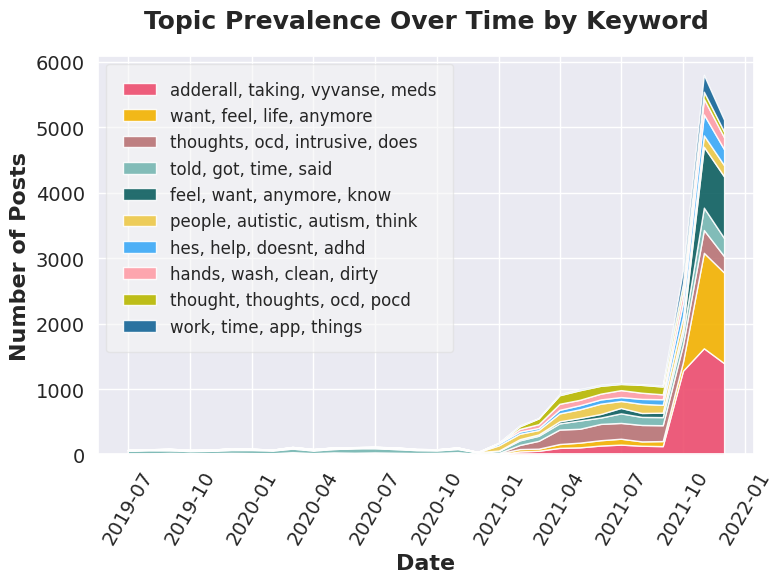

Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topic_distribution.png


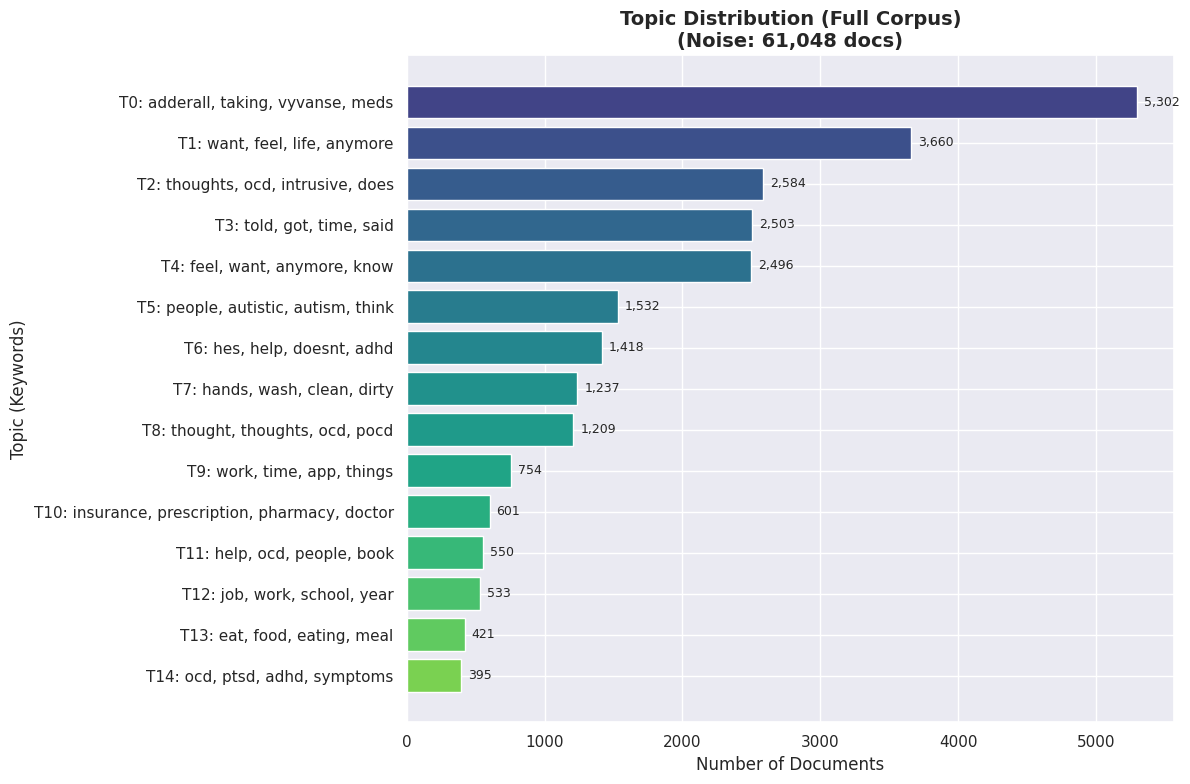

Skipping risk-by-topic: no 'label' column in df.
Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topic_words_heatmap.png


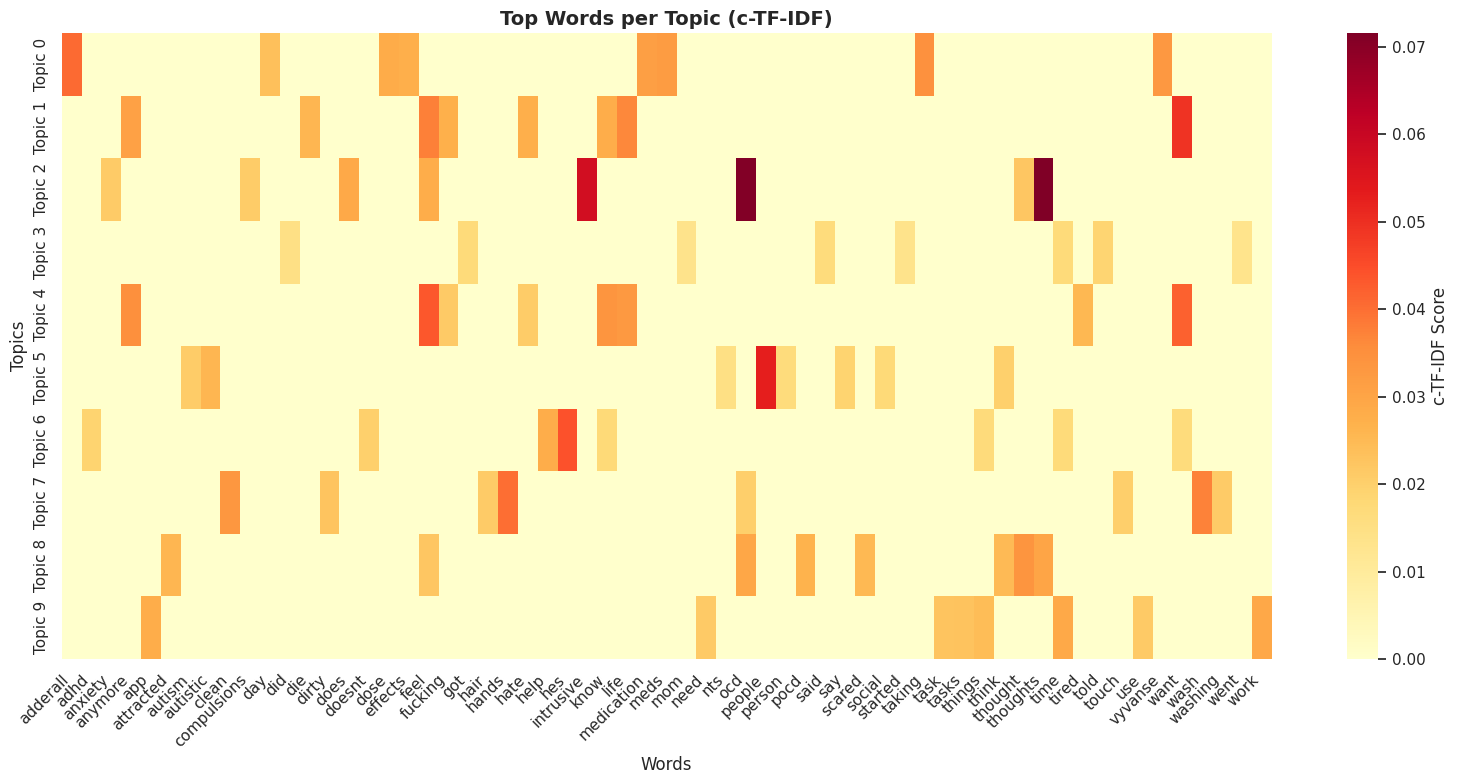

Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topics_per_subreddit.png


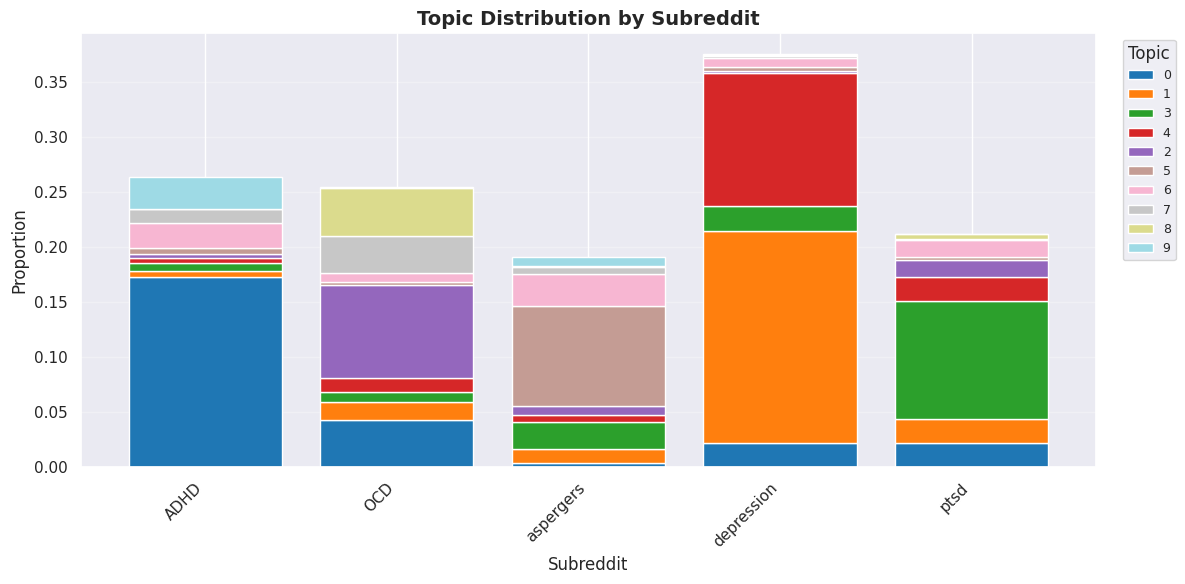

Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topic_similarity.png


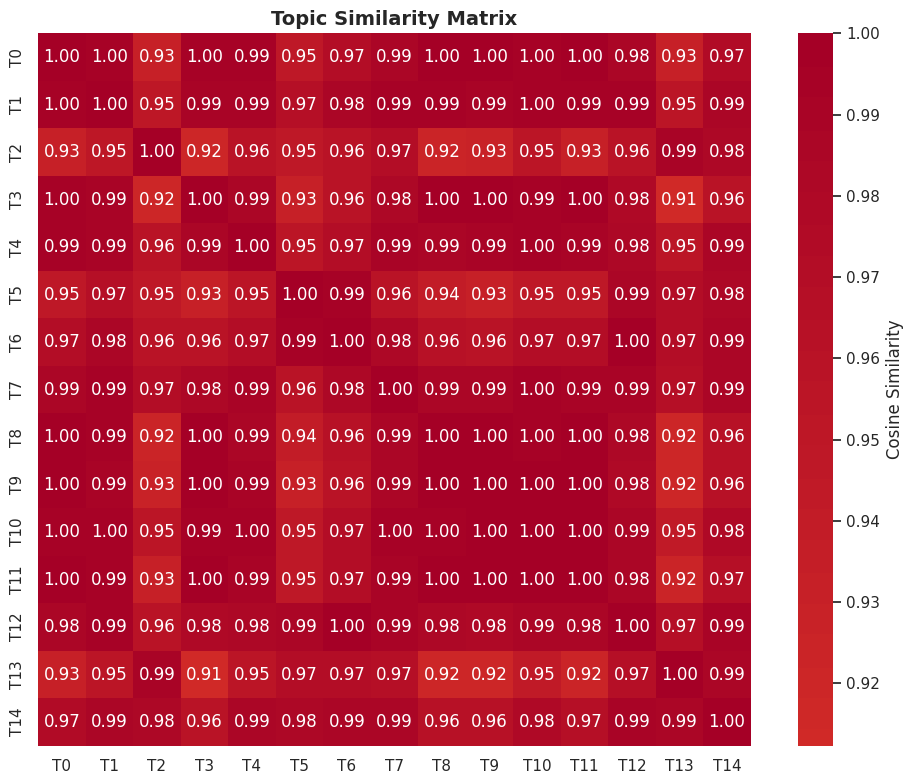

Saved: /content/drive/MyDrive/yinjasim/outputs/figures/topic_trends.png


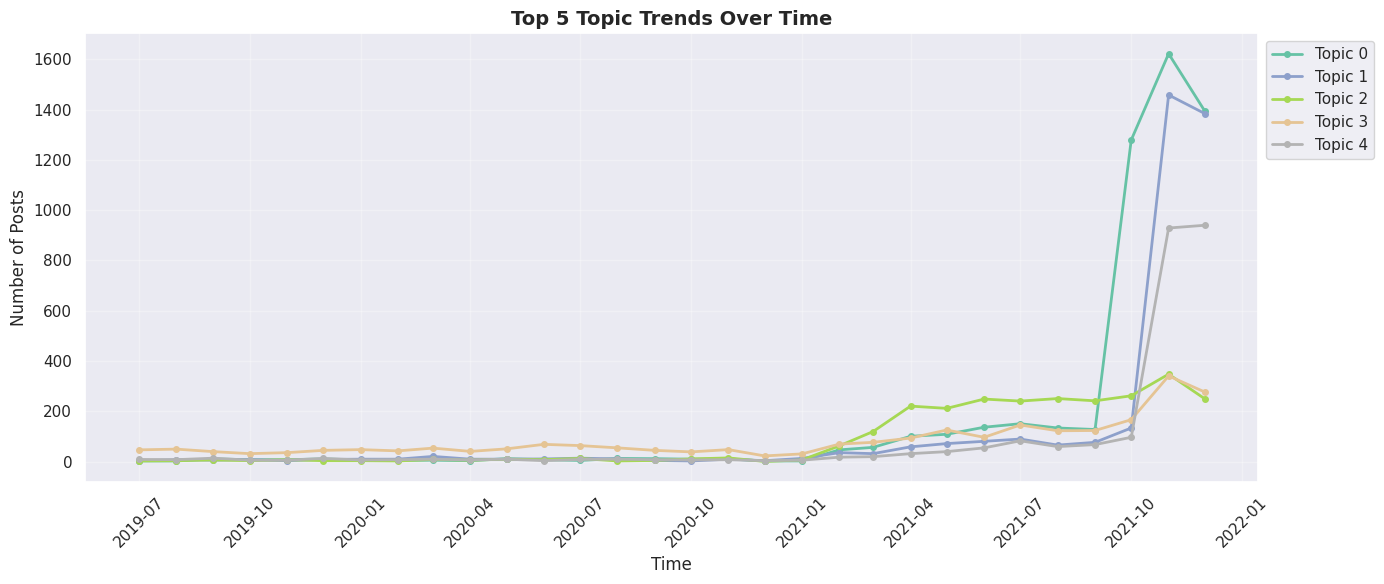


All figures saved under: /content/drive/MyDrive/yinjasim/outputs/figures


In [13]:
# Generate all figures
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Compute monthly prevalence
if "created_utc" not in df.columns:
    raise ValueError("Need column created_utc for time-based plots.")

prevalence = get_topic_prevalence_over_time(
    df, topic_col="topic", time_col="created_utc", freq="M"
)
print(f"Prevalence shape: {prevalence.shape}")
prevalence.to_csv(RESULTS_DIR / "topic_prevalence_over_time.csv")
print(f"Saved: {RESULTS_DIR / 'topic_prevalence_over_time.csv'}")

# 1. Topic prevalence over time (Paru's styling)
plot_topic_prevalence_over_time(
    prevalence,
    save_path=FIGURES_DIR / "topic_prevalence_over_time.png",
    title="Topic Prevalence Over Time by Keyword",
    topic_model=topic_model,
)

# 2. Topic distribution (horizontal bar with keywords)
plot_topic_distribution(
    labels,
    topic_model,
    top_n=15,
    save_path=FIGURES_DIR / "topic_distribution.png",
    title="Topic Distribution (Full Corpus)",
)

# 3. Risk distribution by topic (if labels available)
if "label" in df.columns:
    plot_topic_risk_distribution(
        df, topic_model,
        topic_col="topic", risk_col="label",
        top_n=15,
        save_path=FIGURES_DIR / "topic_risk_distribution.png",
        title="Risk Distribution by Topic",
    )
else:
    print("Skipping risk-by-topic: no 'label' column in df.")

# 4. Topic words heatmap
plot_topic_words_heatmap(
    topic_model,
    top_n_topics=10, top_n_words=8,
    save_path=FIGURES_DIR / "topic_words_heatmap.png",
    title="Top Words per Topic (c-TF-IDF)",
)

# 5. Topics per subreddit
if "subreddit" in df.columns:
    plot_topics_per_subreddit(
        df, topic_col="topic", subreddit_col="subreddit",
        top_n_topics=10,
        save_path=FIGURES_DIR / "topics_per_subreddit.png",
        title="Topic Distribution by Subreddit",
    )
else:
    print("Skipping topics_per_subreddit: no 'subreddit' column.")

# 6. Topic similarity heatmap
plot_topic_similarity_heatmap(
    topic_model, top_n_topics=15,
    save_path=FIGURES_DIR / "topic_similarity.png",
    title="Topic Similarity Matrix",
)

# 7. Topic trend lines
plot_topic_trend_lines(
    prevalence, top_n_topics=5,
    save_path=FIGURES_DIR / "topic_trends.png",
    title="Top 5 Topic Trends Over Time",
)

print(f"\nAll figures saved under: {FIGURES_DIR}")

## 8. Save Results

In [14]:
# Create topic names from keywords
topic_names = {}
for t in topic_model.get_topics():
    words = topic_model.get_topic(t)
    if words:
        topic_names[t] = '_'.join([w for w, _ in words[:5]])
    else:
        topic_names[t] = f"topic_{t}"

df["topic_name"] = df["topic"].map(topic_names)

# Save full corpus with topics
df.to_csv(DATA_DIR / "corpus_with_topics.csv", index=False)
print(f"Saved: {DATA_DIR / 'corpus_with_topics.csv'}")

# Save topic info
topic_info.to_csv(RESULTS_DIR / "bertopic_topic_info.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'bertopic_topic_info.csv'}")

# Save integration CSV (for Paru)
integration_df = df[["id", "topic", "topic_name", "topic_probs"]].rename(columns={"topic": "topic_id"})
integration_df.to_csv(RESULTS_DIR / "topics_for_integration.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'topics_for_integration.csv'}")

# Save prevalence
prevalence = get_topic_prevalence_over_time(df)
prevalence.to_csv(RESULTS_DIR / "topic_prevalence_over_time.csv")
print(f"Saved: {RESULTS_DIR / 'topic_prevalence_over_time.csv'}")

Saved: /content/drive/MyDrive/yinjasim/data/corpus_with_topics.csv
Saved: /content/drive/MyDrive/yinjasim/outputs/results/bertopic_topic_info.csv
Saved: /content/drive/MyDrive/yinjasim/outputs/results/topics_for_integration.csv
Saved: /content/drive/MyDrive/yinjasim/outputs/results/topic_prevalence_over_time.csv


---

## 9. Topic Modeling on Paru's Labeled Data (Integration)

This section runs BERTopic on Paru's annotated train/val sets so we have both topic labels and risk labels on the same data for integration analysis.

In [ ]:
# Path to labeled data (adjust if different)
PARU_DATA_DIR = DRIVE_BASE / "labeled_data"  # <- Change this to your labeled data folder

# Check if files exist
train_path = PARU_DATA_DIR / "train_labeled_set.csv"
val_path = PARU_DATA_DIR / "val_labeled_set.csv"

if not train_path.exists():
    print(f"WARNING: {train_path} not found!")
    print("Please upload labeled data or adjust PARU_DATA_DIR path.")
else:
    print(f"Found labeled data at {PARU_DATA_DIR}")

In [16]:
# Load and combine Paru's labeled data
if train_path.exists():
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path) if val_path.exists() else pd.DataFrame()

    labeled_df = pd.concat([train_df, val_df], ignore_index=True)
    labeled_df = labeled_df.dropna(subset=["text"])
    print(f"Labeled data: {len(labeled_df)} posts")
    print(f"Risk label distribution:")
    print(labeled_df["label"].value_counts())

    # Prepare documents
    labeled_docs = labeled_df["text"].fillna("").astype(str).tolist()

Labeled data: 1060 posts
Risk label distribution:
label
Moderate Risk    308
Low Risk         258
No Risk          239
Severe Risk      167
Unknown           88
Name: count, dtype: int64


In [17]:
# Compute embeddings for labeled data (small dataset, ~2-3 minutes)
LABELED_EMBEDDINGS_PATH = DRIVE_BASE / "embeddings_labeled_mentalbert.npy"

if 'labeled_docs' in dir() and len(labeled_docs) > 0:
    if LABELED_EMBEDDINGS_PATH.exists():
        print(f"Loading saved labeled embeddings...")
        labeled_embeddings = np.load(LABELED_EMBEDDINGS_PATH)
    else:
        print(f"Computing embeddings for {len(labeled_docs)} labeled documents...")
        labeled_embeddings = compute_embeddings(labeled_docs, EMBEDDING_MODEL, verbose=True)
        np.save(LABELED_EMBEDDINGS_PATH, labeled_embeddings)
        print(f"Saved to {LABELED_EMBEDDINGS_PATH}")

    print(f"Labeled embeddings: {labeled_embeddings.shape}")

Loading saved labeled embeddings...
Labeled embeddings: (1060, 768)


In [18]:
# Run BERTopic on labeled data (smaller dataset = smaller cluster size)
if 'labeled_embeddings' in dir():
    topic_model_labeled, labels_labeled, probs_labeled = run_bertopic_on_embeddings(
        labeled_docs,
        labeled_embeddings,
        umap_n_neighbors=10,
        umap_n_components=5,
        umap_min_dist=0.0,
        hdbscan_min_cluster_size=30,  # Smaller for ~1000 docs
        hdbscan_min_samples=5,
        seed=SEED,
    )

    # Add topics to labeled dataframe
    labeled_df["topic"] = labels_labeled
    labeled_df["topic_probs"] = [p.max() if hasattr(p, '__len__') and len(p) > 0 else (p if p else 0) for p in probs_labeled]

    # Create topic names
    labeled_topic_names = {}
    for t in topic_model_labeled.get_topics():
        words = topic_model_labeled.get_topic(t)
        if words:
            labeled_topic_names[t] = '_'.join([w for w, _ in words[:5]])
        else:
            labeled_topic_names[t] = f"topic_{t}"
    labeled_df["topic_name"] = labeled_df["topic"].map(labeled_topic_names)

    print("\nTopic distribution in labeled data:")
    print(labeled_df["topic"].value_counts().head(10))

2026-04-23 02:09:15,503 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Running BERTopic...
  UMAP: n_neighbors=10, n_components=5, min_dist=0.0
  HDBSCAN: min_cluster_size=30, min_samples=5


2026-04-23 02:09:22,567 - BERTopic - Dimensionality - Completed ✓
2026-04-23 02:09:22,568 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 02:09:22,631 - BERTopic - Cluster - Completed ✓
2026-04-23 02:09:22,634 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 02:09:22,810 - BERTopic - Representation - Completed ✓


Done! Topics: 5, Noise: 250 (23.6%)

Topic distribution in labeled data:
topic
 0    454
-1    250
 1    172
 2    103
 3     51
 4     30
Name: count, dtype: int64


In [19]:
# Save labeled data with topics
if 'labeled_df' in dir() and 'topic' in labeled_df.columns:
    output_path = DATA_DIR / "labeled_with_topics.csv"
    labeled_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

    # Show topic × risk distribution
    print("\nTopic × Risk Distribution:")
    if "label" in labeled_df.columns:
        crosstab = pd.crosstab(labeled_df["topic"], labeled_df["label"])
        display(crosstab)

Saved: /content/drive/MyDrive/yinjasim/data/labeled_with_topics.csv

Topic × Risk Distribution:


label,Low Risk,Moderate Risk,No Risk,Severe Risk,Unknown
topic,,,,,
-1,73,54,75,17,31
0,94,175,51,125,9
1,38,21,88,6,19
2,36,41,15,11,0
3,9,5,8,1,28
4,8,12,2,7,1


## 10. Summary

In [20]:
print("=" * 60)
print("Topic Modeling Complete!")
print("=" * 60)
print(f"\nFull corpus:")
print(f"  Documents: {len(documents):,}")
print(f"  Topics: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"  Noise: {labels.count(-1):,} ({100*labels.count(-1)/len(labels):.1f}%)")

if 'labeled_df' in dir() and 'topic' in labeled_df.columns:
    print(f"\nLabeled data (for Paru):")
    print(f"  Documents: {len(labeled_df):,}")
    print(f"  Topics: {len(set(labels_labeled)) - (1 if -1 in labels_labeled else 0)}")

print(f"\nOutputs saved to:")
print(f"  - {DATA_DIR / 'corpus_with_topics.csv'}")
print(f"  - {RESULTS_DIR / 'topics_for_integration.csv'}")
if 'labeled_df' in dir():
    print(f"  - {DATA_DIR / 'labeled_with_topics.csv'}")

Topic Modeling Complete!

Full corpus:
  Documents: 87,733
  Topics: 21
  Noise: 61,048 (69.6%)

Labeled data (for Paru):
  Documents: 1,060
  Topics: 5

Outputs saved to:
  - /content/drive/MyDrive/yinjasim/data/corpus_with_topics.csv
  - /content/drive/MyDrive/yinjasim/outputs/results/topics_for_integration.csv
  - /content/drive/MyDrive/yinjasim/data/labeled_with_topics.csv
